# Wavefront visualisation: perfect beam down, aberrated beam up

Visualises the two fields `optics/generate_wavefront.py` builds for an
interpolated (`wtype=interpolated`) ais++ beam under the mirror-reflection
model: a perfect Gaussian beam travels down to the retroreflecting mirror
at z=0, and picks up a wavefront aberration (here: a sum of transverse
Fourier modes) on reflection, becoming the upward beam.

Run this after `generate_wavefront.py` (or just edit the config cell below
to match what you generated -- this notebook rebuilds the fields directly
via aisoptics rather than reading the exported HDF5, so it doesn't need to
match on-disk state).

In [1]:
import sys
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

REPO = Path('..').resolve()
sys.path.insert(0, str(REPO.parent / 'local' / 'aispy'))
from aispy.utils import kz as AISPY_KZ

from aisoptics import Backend, GaussianBeam, GridSpec, CompositeField
from aisoptics.fields.perturbations import FourierModePerturbation, FourierPerturbation

# --- config: match generate_wavefront.py's defaults / your --mode flags ---
WAVELENGTH = 2 * np.pi / float(AISPY_KZ)
ZR = 450.085
WAIST = np.sqrt(2 * ZR / float(AISPY_KZ))
FOCUS_Z = 0.0
MODES = [
    FourierModePerturbation(qx=1571.0, qy=0.0, amplitude=0.15, phase=0.0),
    # add more FourierModePerturbation(...) here for multiple modes
]

print(f'wavelength={WAVELENGTH*1e9:.2f} nm  waist={WAIST*1e3:.3f} mm')

wavelength=698.45 nm  waist=10.003 mm


In [2]:
backend = Backend("numpy")
down_beam = GaussianBeam(wavelength=WAVELENGTH, waist=WAIST, focus_z=FOCUS_Z,
                          propagation_direction="-z", backend=backend)
up_beam_ref = GaussianBeam(wavelength=WAVELENGTH, waist=WAIST, focus_z=FOCUS_Z,
                            propagation_direction="+z", backend=backend)
up_field_obj = CompositeField(reference=up_beam_ref,
                               phase_perturbation=FourierPerturbation(modes=MODES),
                               mode="exact") if MODES else up_beam_ref

### Phase and amplitude at the mirror plane (z=0)

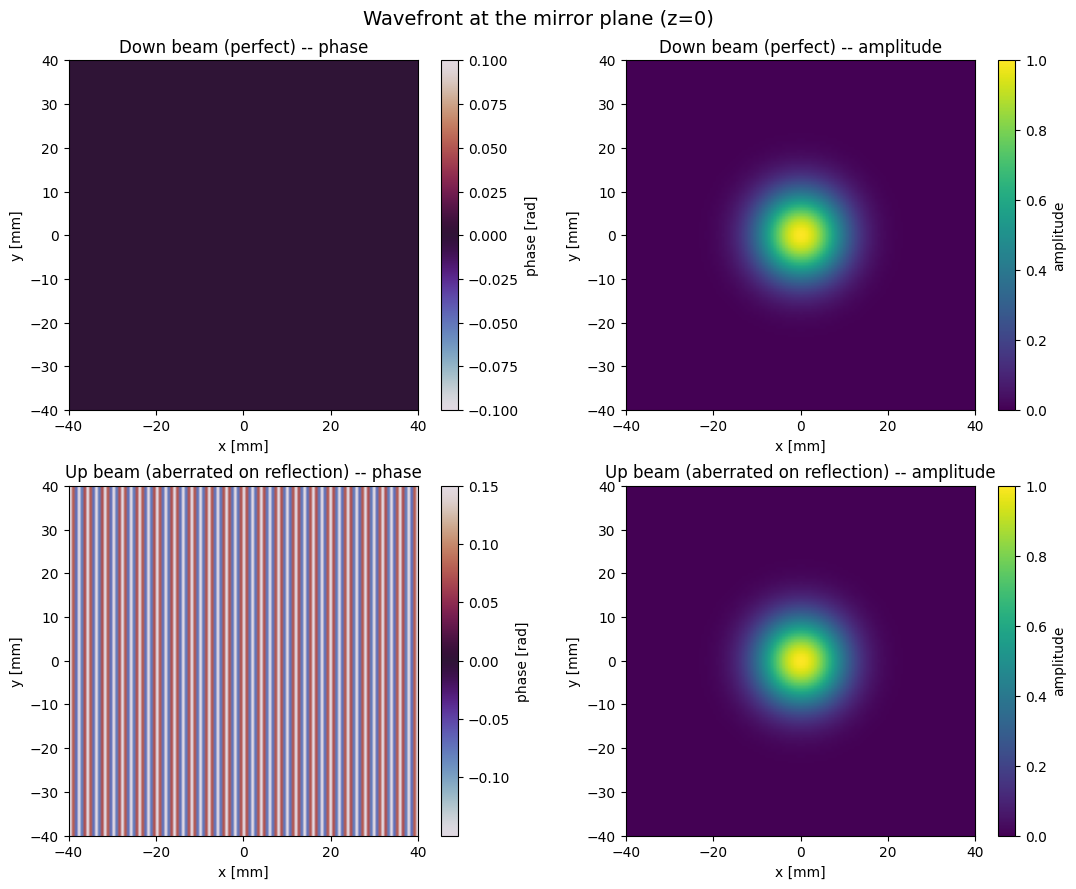

In [3]:
N = 121
half = 4 * WAIST   # a few beam waists across
x = np.linspace(-half, half, N)
y = np.linspace(-half, half, N)
X, Y = np.meshgrid(x, y, indexing='ij')
Z = np.zeros_like(X)

down_complex = down_beam.complex_amplitude(X, Y, Z)
up_complex = up_field_obj.complex_amplitude(X, Y, Z)

down_phase, down_amp = np.angle(down_complex), np.abs(down_complex)
up_phase, up_amp = np.angle(up_complex), np.abs(up_complex)

fig, axes = plt.subplots(2, 2, figsize=(11, 9))
extent = [x[0]*1e3, x[-1]*1e3, y[0]*1e3, y[-1]*1e3]

im = axes[0,0].imshow(down_phase.T, origin='lower', extent=extent, cmap='twilight')
plt.colorbar(im, ax=axes[0,0], label='phase [rad]')
axes[0,0].set_title('Down beam (perfect) -- phase')

im = axes[0,1].imshow(down_amp.T, origin='lower', extent=extent, cmap='viridis')
plt.colorbar(im, ax=axes[0,1], label='amplitude')
axes[0,1].set_title('Down beam (perfect) -- amplitude')

im = axes[1,0].imshow(up_phase.T, origin='lower', extent=extent, cmap='twilight')
plt.colorbar(im, ax=axes[1,0], label='phase [rad]')
axes[1,0].set_title('Up beam (aberrated on reflection) -- phase')

im = axes[1,1].imshow(up_amp.T, origin='lower', extent=extent, cmap='viridis')
plt.colorbar(im, ax=axes[1,1], label='amplitude')
axes[1,1].set_title('Up beam (aberrated on reflection) -- amplitude')

for ax in axes.flat:
    ax.set_xlabel('x [mm]'); ax.set_ylabel('y [mm]')
fig.suptitle('Wavefront at the mirror plane (z=0)', fontsize=14)
fig.tight_layout()
plt.show()

### Just the aberration: up-beam phase minus down-beam phase

Isolates what the mirror actually did to the wavefront -- should match the
Fourier-mode sum in `MODES` above (this is a direct sanity check that the
aberration you specified is what actually got sampled).

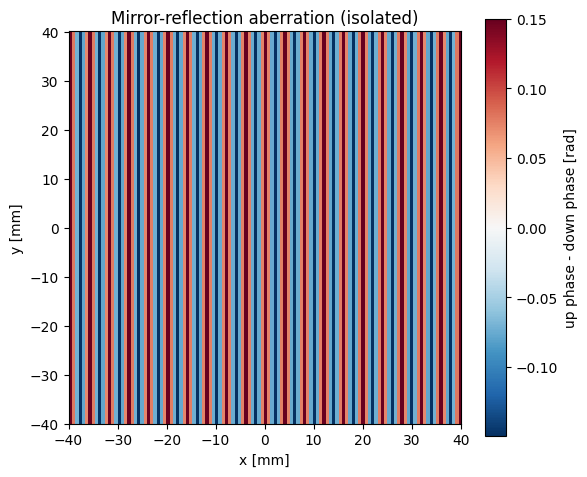

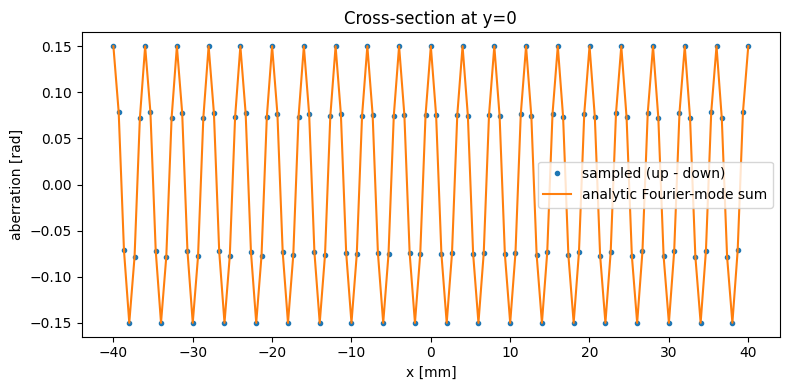

In [4]:
aberration = np.angle(np.exp(1j * (up_phase - down_phase)))  # wrap to (-pi, pi]

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(aberration.T, origin='lower', extent=extent, cmap='RdBu_r')
plt.colorbar(im, ax=ax, label='up phase - down phase [rad]')
ax.set_title('Mirror-reflection aberration (isolated)')
ax.set_xlabel('x [mm]'); ax.set_ylabel('y [mm]')
plt.tight_layout()
plt.show()

# 1D cross-section at y=0, compared to the analytic sum of Fourier modes
iy0 = N // 2
analytic = sum(m.amplitude * np.cos(m.qx * x + m.qy * 0.0 + m.phase) for m in MODES) if MODES else np.zeros_like(x)
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(x * 1e3, aberration[:, iy0], 'o', ms=3, label='sampled (up - down)')
ax.plot(x * 1e3, analytic, '-', lw=1.5, label='analytic Fourier-mode sum')
ax.set_xlabel('x [mm]'); ax.set_ylabel('aberration [rad]')
ax.set_title('Cross-section at y=0')
ax.legend()
plt.tight_layout()
plt.show()

### 3D surface of the up-beam wavefront

Same phase data as above, as a surface -- sometimes easier to read off the
mode structure (ripples, tilt, curvature) than a 2D heatmap.

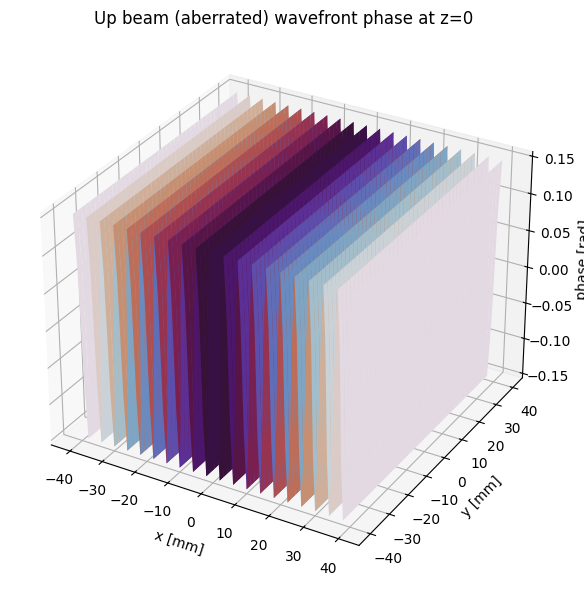

In [5]:
fig = plt.figure(figsize=(9, 6))
ax = fig.add_subplot(111, projection='3d')
ax.plot_surface(X * 1e3, Y * 1e3, up_phase, cmap='twilight', linewidth=0, antialiased=True)
ax.set_xlabel('x [mm]'); ax.set_ylabel('y [mm]'); ax.set_zlabel('phase [rad]')
ax.set_title('Up beam (aberrated) wavefront phase at z=0')
plt.tight_layout()
plt.show()